In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Removed: import seaborn as sns 
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, \
                            precision_score, recall_score, f1_score, \
                            classification_report
import tensorflow as tf
import os # Needed for saving plots in callback

# Assume your val_dataset is already defined and batched
# Example: val_dataset = tf.keras.preprocessing.image_dataset_from_directory(...)

# ---------------------------------------------------------------------------
# 1. Standalone Function for Post-Training Analysis (Matplotlib)
# ---------------------------------------------------------------------------

def analyze_model_outputs(model: tf.keras.Model, 
                          val_dataset: tf.data.Dataset, 
                          dataset_name: str = "Validation"):
    """
    Analyzes model predictions on a given dataset using Matplotlib for histograms.

    Args:
        model: The trained Keras model.
        val_dataset: The tf.data.Dataset to evaluate on.
        dataset_name: Name for plot titles (e.g., "Validation", "Test").
    """
    print(f"\n--- Analyzing Model Outputs on {dataset_name} Set ---")

    # --- Get Predictions and True Labels ---
    print("Gathering predictions and true labels...")
    try:
        predictions_raw = model.predict(val_dataset)
        true_labels = []
        for _, y_batch in val_dataset:
            true_labels.append(y_batch.numpy())
        true_labels = np.concatenate(true_labels, axis=0).flatten()
        predictions_proba = predictions_raw.flatten()

        if len(predictions_proba) != len(true_labels):
             print(f"Warning: Number of predictions ({len(predictions_proba)}) "
                   f"does not match number of labels ({len(true_labels)}). "
                   f"Check dataset configuration.")
             # Attempt to reconcile if predictions has an extra dim (unlikely here)
             if predictions_proba.shape[0] != true_labels.shape[0] and len(predictions_proba.shape) > 1:
                 print("Attempting to flatten predictions further.")
                 predictions_proba = predictions_proba.reshape(-1) # Or adjust based on actual shape
                 if len(predictions_proba) != len(true_labels):
                     raise ValueError("Cannot reconcile prediction and label shapes.")

    except Exception as e:
        print(f"Error during prediction or label extraction: {e}")
        print("Check dataset structure and model output shape.")
        return

    print(f"Successfully gathered {len(true_labels)} labels and predictions.")

    # --- Plot Histogram of Predicted Probabilities (Matplotlib) ---
    print("Plotting histogram of predicted probabilities...")
    plt.figure(figsize=(10, 6))
    # Use plt.hist instead of sns.histplot
    # density=True normalizes the histogram (area sums to 1)
    # alpha adds transparency
    plt.hist(predictions_proba, bins=50, density=True, alpha=0.75, color='blue', edgecolor='black') 
    plt.title(f'Histogram of Predicted Probabilities ({dataset_name} Set)')
    plt.xlabel('Predicted Probability (Class 1)')
    plt.ylabel('Density') # Changed label to Density since density=True
    plt.grid(True, axis='y', linestyle='--')
    plt.show()

    # --- Calculate AUC ---
    try:
        auc_score = roc_auc_score(true_labels, predictions_proba)
        print(f"\nArea Under ROC Curve (AUC): {auc_score:.4f}")
    except ValueError as e:
        print(f"\nCould not calculate AUC: {e}. This might happen if only one class is present in true labels.")
        auc_score = None

    # --- Find Best Threshold based on F1 Score ---
    print("\nCalculating metrics across different thresholds...")
    precision_pts, recall_pts, thresholds = precision_recall_curve(true_labels, predictions_proba)
    thresholds = thresholds[:len(precision_pts)-1] 
    f1_scores = []
    for p, r in zip(precision_pts[:-1], recall_pts[:-1]):
         if (p + r) > 0: f1 = 2 * (p * r) / (p + r)
         else: f1 = 0.0
         f1_scores.append(f1)

    if not f1_scores:
         print("Could not calculate F1 scores across thresholds.")
         best_threshold = 0.5
         best_f1 = 0.0
    else:
         best_f1_idx = np.argmax(f1_scores)
         best_threshold = thresholds[best_f1_idx]
         best_f1 = f1_scores[best_f1_idx]
         print(f"Best Threshold (Maximizing F1): {best_threshold:.4f}")
         print(f"Best F1 Score at this threshold: {best_f1:.4f}")

         # Optional: Plot Precision-Recall Curve (already using Matplotlib)
         plt.figure(figsize=(8, 6))
         pr_auc = auc(recall_pts, precision_pts)
         plt.plot(recall_pts, precision_pts, label=f'PR curve (area = {pr_auc:.2f})')
         plt.scatter(recall_pts[best_f1_idx], precision_pts[best_f1_idx], marker='o', color='red', label=f'Best F1 Threshold ({best_threshold:.2f})')
         plt.xlabel('Recall')
         plt.ylabel('Precision')
         plt.title(f'Precision-Recall Curve ({dataset_name} Set)')
         plt.legend()
         plt.grid(True)
         plt.show()

    # --- Calculate Metrics at the Chosen Threshold ---
    print(f"\nMetrics using threshold = {best_threshold:.4f}:")
    final_predictions = (predictions_proba >= best_threshold).astype(int)
    try:
        print(classification_report(true_labels, final_predictions))
    except ValueError as e:
        print(f"Could not generate classification report: {e}")

    print("--- Analysis Complete ---")


# ---------------------------------------------------------------------------
# 2. Custom Callback for Analysis During Training (Matplotlib)
# ---------------------------------------------------------------------------

class OutputAnalysisCallback(tf.keras.callbacks.Callback):
    """
    Callback to analyze model outputs (histogram, metrics) during training 
    using Matplotlib for histograms.
    """
    def __init__(self, validation_data, log_dir, run_freq=5, dataset_name="Validation"):
        """
        Args:
            validation_data (tf.data.Dataset): The validation dataset.
            log_dir (str): Directory to save plots.
            run_freq (int): How often (in epochs) to run the analysis.
            dataset_name (str): Name for plot titles.
        """
        super().__init__()
        self.validation_data = validation_data
        self.log_dir = log_dir
        self.run_freq = run_freq
        self.dataset_name = dataset_name
        
        print("Callback: Extracting true labels from validation data...")
        try:
            true_labels_list = []
            for _, y_batch in self.validation_data: 
                true_labels_list.append(y_batch.numpy())
            self.true_labels = np.concatenate(true_labels_list, axis=0).flatten()
            print(f"Callback: Successfully extracted {len(self.true_labels)} labels.")
        except Exception as e:
            print(f"Callback Error: Failed to extract true labels - {e}. Analysis might fail.")
            self.true_labels = None
            
        os.makedirs(self.log_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.run_freq == 0 and self.true_labels is not None:
            print(f"\n--- Running Output Analysis Callback: Epoch {epoch + 1} ---")
            
            # --- Get Predictions ---
            predictions_raw = self.model.predict(self.validation_data)
            predictions_proba = predictions_raw.flatten()

            if len(predictions_proba) != len(self.true_labels):
                print(f"Callback Warning: Epoch {epoch+1} - Predictions ({len(predictions_proba)}) "
                      f"mismatched with labels ({len(self.true_labels)}). Skipping analysis.")
                return

            # --- Plot Histogram (Matplotlib) ---
            plt.figure(figsize=(10, 6))
            # Use plt.hist instead of sns.histplot
            plt.hist(predictions_proba, bins=50, density=True, alpha=0.75, color='blue', edgecolor='black')
            plt.title(f'Histogram of Predicted Probabilities (Epoch {epoch + 1} - {self.dataset_name})')
            plt.xlabel('Predicted Probability (Class 1)')
            plt.ylabel('Density') # Changed label
            plt.grid(True, axis='y', linestyle='--')
            plot_path = os.path.join(self.log_dir, f'predictions_hist_epoch_{epoch + 1}.png')
            try:
                plt.savefig(plot_path)
                print(f"Saved prediction histogram to {plot_path}")
            except Exception as e:
                print(f"Error saving histogram: {e}")
            plt.close() # Close plot to avoid displaying it now

            # --- Calculate AUC ---
            try:
                 auc_score = roc_auc_score(self.true_labels, predictions_proba)
                 print(f"Epoch {epoch + 1} - AUC: {auc_score:.4f}")
            except ValueError as e:
                 print(f"Epoch {epoch + 1} - Could not calculate AUC: {e}")

            # --- Find Best Threshold & F1 ---
            precision_pts, recall_pts, thresholds = precision_recall_curve(self.true_labels, predictions_proba)
            thresholds = thresholds[:len(precision_pts)-1]
            f1_scores = []
            for p, r in zip(precision_pts[:-1], recall_pts[:-1]):
                 f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
                 f1_scores.append(f1)

            if f1_scores:
                 best_f1_idx = np.argmax(f1_scores)
                 best_threshold = thresholds[best_f1_idx]
                 best_f1 = f1_scores[best_f1_idx]
                 print(f"Epoch {epoch + 1} - Best F1 Threshold: {best_threshold:.4f} (F1: {best_f1:.4f})")
            else:
                 print(f"Epoch {epoch + 1} - Could not calculate F1 scores across thresholds.")

            print(f"--- Callback Analysis Complete: Epoch {epoch + 1} ---\n")

# ---------------------------------------------------------------------------
# How to Use (No changes needed here from previous version)
# ---------------------------------------------------------------------------
# (Use the standalone function or integrate the callback into train_transfer_model 
# exactly as described in the previous response)
# ...

2025-04-11 13:03:56.849862: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-11 13:03:56.849914: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-11 13:03:56.849954: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-11 13:03:56.857737: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import json
import numpy as np
import os
import sys
import time
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
import src.data_pipeline as dp
from src.config import Config
from src.model import create_model
from src.train import compile_model

In [3]:
my_config = Config()
# my_config.MODEL_ARCHITECTURE = 'resnet50'
my_config.SHUFFLE_DATASET = False
params = {"MASK_VALUE": 128, "AUGMENT_DATA": True, "NORMALIZE_IMAGES": True,  "MASK_BG": True, "HEAD_DENSE_UNITS": 128, "MODEL_ARCHITECTURE": 'vgg16', 'FINE_TUNE_FROM_LAYER': 15, 'HEAD_ARCHITECTURE': "shallow"}
for key, value in params.items():
    setattr(my_config, key, value)        
# my_config.INITIAL_LR = 0.01
raw_json_path = "C:/Users/anedaeij23/Project/tooth_classification_project/data/raw/complete_toothwise_annotations.json"
intrim_dir = "/home/arash/tooth_classification_project/data/processed"
img_dir = "C:/Users/anedaeij23/Project/tooth_classification_project/data/raw"

In [4]:
my_config.SHUFFLE_DATASET

False

In [5]:
ds_json_path = os.path.join(intrim_dir, "Pla_filtered_test.json")
val_records = dp.parse_dataset_json(ds_json_path, my_config, is_train_ds=False)
val_records_updated, _   = dp.preprocess_and_save_images(val_records, my_config, "test")
val_ds   = dp.build_tf_dataset_from_preprocessed(val_records_updated, my_config)

Processed folder '/home/arash/tooth_classification_project/data/processed/Pla_128_42_1_1_1_0.25_0.015' and records file exist. Loading records...


2025-04-11 13:03:58.752210: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-11 13:03:58.757403: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-11 13:03:58.757451: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-11 13:03:58.760548: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-11 13:03:58.760623: I tensorflow/compile

In [6]:
def print_dataset_stats(dataset, name="Dataset"):
    total = 0
    class_counts = {0: 0, 1: 0}
    for x, y in dataset:
        total += len(y)
        for label in y.numpy():
            class_counts[int(label)] += 1
    print(f"{name} statistics:")
    print(f"Total samples: {total}")
    print(f"Class distribution: {class_counts}")

# Add before training
print_dataset_stats(val_ds, "Validation")

Validation statistics:
Total samples: 460
Class distribution: {0: 380, 1: 80}


###############Base model frozen

Analyzing model state AFTER INITIAL training:

--- Analyzing Model Outputs on Validation (Initial) Set ---
Gathering predictions and true labels...


2025-04-11 13:04:00.569254: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2025-04-11 13:04:00.577824: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-04-11 13:04:00.675958: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


15/15 [==============================] - 7s 219ms/step
Successfully gathered 460 labels and predictions.
Plotting histogram of predicted probabilities...


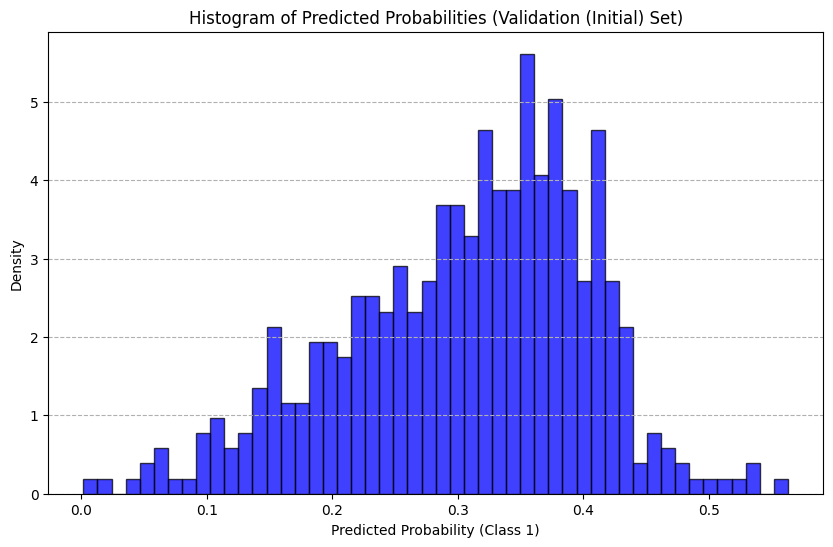


Area Under ROC Curve (AUC): 0.6722

Calculating metrics across different thresholds...
Best Threshold (Maximizing F1): 0.3618
Best F1 Score at this threshold: 0.4196


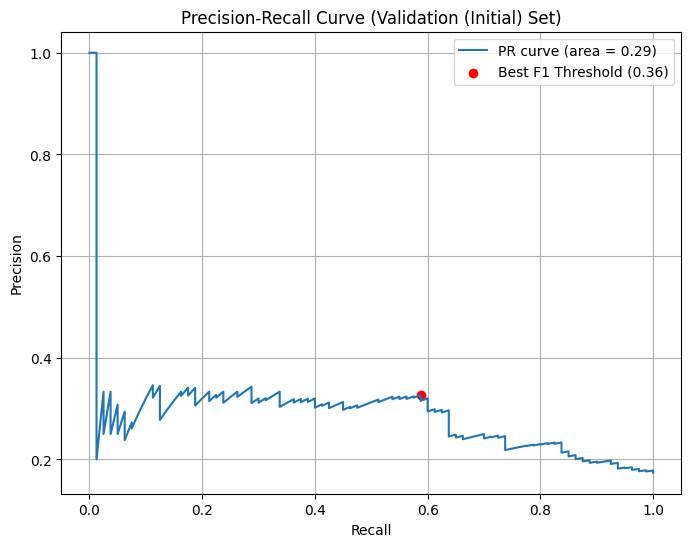


Metrics using threshold = 0.3618:
              precision    recall  f1-score   support

         0.0       0.90      0.74      0.81       380
         1.0       0.33      0.59      0.42        80

    accuracy                           0.72       460
   macro avg       0.61      0.67      0.62       460
weighted avg       0.80      0.72      0.74       460

--- Analysis Complete ---


In [7]:
# ---------------------------------------------------------------------------
# How to Use
# ---------------------------------------------------------------------------

# --- Using the Standalone Function ---
# Assume 'mymodel' is your trained model after calling train_transfer_model
# or loaded from saved weights.
# Assume 'val_dataset' is your validation tf.data.Dataset

# analyze_model_outputs(mymodel, val_dataset, dataset_name="Validation")

# If you saved weights after initial training and want to analyze that state:
initial_weights_path = os.path.join("/home/arash/tooth_classification_project/logs/tensorboard", "vgg16/20250411-125915/initial_weights_1_.h5")#initial_weights_1_.h5") # Get the correct path
# model_arch = 'ConvNeXtTiny' # Or whichever architecture was used
# input_s = (224, 224, 3) # Use your actual input shape
model_for_initial_analysis = create_model(my_config, 'transfer', trainable_base = False) # Build with same structure
model_for_initial_analysis.load_weights(initial_weights_path)
model_for_initial_analysis = compile_model(model_for_initial_analysis, my_config, my_config.INITIAL_LR)
print("\nAnalyzing model state AFTER INITIAL training:")
analyze_model_outputs(model_for_initial_analysis, val_ds, dataset_name="Validation (Initial)")

In [8]:
model_for_initial_analysis.summary()

Model: "vgg16_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 preprocessing_layer (Lambd  (None, 256, 256, 3)       0         
 a)                                                              
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 head_gap (GlobalAveragePoo  (None, 512)               0         
 ling2D)                                                         
                                                                 
 head_bn_1 (BatchNormalizat  (None, 512)               2048      
 ion)                                                            
                                                       

In [9]:
model_for_initial_analysis.layers[2].summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

In [70]:
tf.keras.backend.count_params(model_for_initial_analysis.trainable_weights[0])

512

In [72]:
model_for_initial_analysis.summary(show_trainable=True)

Model: "vgg16_model"
____________________________________________________________________________
 Layer (type)                Output Shape              Param #   Trainable  
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         N          
                                                                            
 preprocessing_layer (Lambd  (None, 256, 256, 3)       0         N          
 a)                                                                         
                                                                            
 vgg16 (Functional)          (None, None, None, 512)   1471468   N          
                                                       8                    
                                                                            
 head_gap (GlobalAveragePoo  (None, 512)               0         N          
 ling2D)                                                                    
                                                       

In [73]:
import tensorflow as tf
import numpy as np

# Define (or load) your model as described in the previous example.

# Calculate the total number of trainable parameters.
trainable_param_count = np.sum([tf.keras.backend.count_params(w) for w in model_for_initial_analysis.trainable_weights])
print("Total trainable parameters:", trainable_param_count)

Total trainable parameters: 67073


In [53]:
int(np.sum([tf.keras.backend.count_params(p) for p in set(model_for_initial_analysis.trainable_weights)]))

TypeError: Variable is unhashable. Instead, use variable.ref() as the key. (Variable: <tf.Variable 'head_bn_1/gamma:0' shape=(512,) dtype=float32, numpy=
array([0.88143176, 0.9972568 , 1.0632827 , 0.9859782 , 1.0379968 ,
       0.9549562 , 1.0210478 , 0.8653844 , 0.99382263, 1.0342201 ,
       0.99753624, 0.9599232 , 0.97913426, 0.9554221 , 0.9491485 ,
       0.87629783, 1.0028113 , 0.89400893, 0.8713806 , 0.90038866,
       0.9669167 , 0.9602815 , 1.1591872 , 0.95641285, 1.1400409 ,
       0.9104136 , 0.96609294, 0.9819718 , 1.3262088 , 0.91479826,
       0.96303827, 0.9914292 , 1.0744984 , 1.0149506 , 1.0399721 ,
       1.0465885 , 1.0886241 , 1.0305048 , 0.96704113, 1.009364  ,
       0.95441896, 1.022038  , 1.0064236 , 0.93561196, 0.88860935,
       1.0916013 , 1.2941059 , 1.040363  , 1.1320016 , 0.9296186 ,
       0.94405174, 0.89168096, 0.92795044, 1.0046976 , 0.9670348 ,
       0.93224066, 0.9729966 , 1.0568566 , 0.91189957, 1.0963845 ,
       0.9489221 , 0.9639649 , 0.815293  ,

In [10]:
# dataset= val_ds
# batch_number= 120
# """
# Prints the records for the desired batch number (1-indexed) from the dataset.

# Args:
#     dataset (tf.data.Dataset): The tf.data.Dataset instance.
#     batch_number (int): The desired batch number (1-indexed).
# """
# # Convert batch_number to zero-indexed for skip: the first batch is batch 0.
# target_idx = batch_number - 1

# # Use skip and take to get the desired batch.
# desired_batch = dataset.skip(target_idx).take(1)

# # Flag to check if batch exists.
# batch_found = False

# for batch in desired_batch:
#     batch_found = True
#     # Assuming each batch is a tuple: (images, labels)
#     images, labels = batch
#     print(f"Batch {batch_number}:")
#     print("Images shape:", images.shape)
#     # For example, print out the labels; you can print images in more detail if needed.
#     print("Labels:", labels.numpy())

# if not batch_found:
#     print(f"Batch {batch_number} not found in the dataset.")

In [11]:
# """
# Plots each image in the specified batch (1-indexed) with its label.

# Args:
#     dataset (tf.data.Dataset): The dataset output from build_tf_dataset_from_preprocessed().
#     batch_number (int): The desired batch number to display (1-indexed).
# """
# # Adjust for 0-index (first batch is batch 0)
# target_idx = batch_number - 1

# # Get the desired batch using skip() and take().
# desired_batch = dataset.skip(target_idx).take(1)

# # Loop through the batch (should have only one batch)
# for batch in desired_batch:
#     # The dataset returns a tuple (images, labels)
#     images, labels = batch
    
#     # Determine number of images in the batch
#     num_images = images.shape[0]
    
#     # Create a figure with one subplot per image
#     plt.figure(figsize=(num_images * 3, 3))
#     for i in range(num_images):
#         plt.subplot(1, num_images, i + 1)
#         # Convert the image tensor to a NumPy array.
#         # If the image values are floats in [0, 255] then convert to uint8, otherwise adjust as needed.
#         image_np = images[i].numpy()
#         # Optionally, if you want to ensure 0-255 format, you might do:
#         if np.issubdtype(image_np.dtype, np.floating):
#             image_np = np.clip(image_np, 0, 255).astype(np.uint8)
#         plt.imshow(image_np)
#         # Print the label as the title
#         plt.title(f"Label: {labels[i].numpy()}")
#         plt.axis("off")
#     plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_probabilities_per_record(trained_model: tf.keras.Model,
                                   val_dataset: tf.data.Dataset,
                                   config: Config,
                                   dataset_name: str = "Validation",
                                   ):
    """
    Gets the final probability predictions (post-sigmoid, pre-threshold) 
    from the model for each record in the validation set and plots them,
    colored by true class, to help assess the classification threshold.

    Args:
        trained_model: The trained Keras model ending with a sigmoid activation 
                       (like the one from your build_pretrained_model function).
        val_dataset: The tf.data.Dataset to evaluate on.
        dataset_name: Name for plot titles (e.g., "Validation", "Test").
    """
    print(f"\n--- Plotting Probabilities (Post-Sigmoid) for {dataset_name} Set ---")

    # --- Get Probability Predictions ---
    # Use the original model directly. Its output IS the probability 
    # because the last layer has sigmoid activation.
    print(f"Getting probability predictions for {dataset_name} set...")
    try:
        # This gets the output AFTER the sigmoid activation
        probabilities = trained_model.predict(val_dataset) 
        # Ensure predictions are flattened to a 1D array
        probabilities = probabilities.flatten() 
    except Exception as e:
        print(f"Error during probability prediction: {e}")
        return
        
    # --- Get True Labels ---
    print("Gathering true labels...")
    try:
        true_labels = []
        # Ensure iteration covers the whole dataset if not cached/repeated
        for _, y_batch in val_dataset: 
            true_labels.append(y_batch.numpy())
        # Ensure labels are flattened to a 1D array
        true_labels = np.concatenate(true_labels, axis=0).flatten()
    except Exception as e:
        print(f"Error extracting true labels: {e}")
        return

    # --- Verify Counts ---
    if len(probabilities) != len(true_labels):
        print(f"\nError: Mismatch between probability count ({len(probabilities)}) "
              f"and label count ({len(true_labels)}).")
        print("Check model's final layer output shape (should be 1) and dataset structure.")
        print("Cannot proceed with plotting.")
        return
        
    print(f"Successfully gathered {len(true_labels)} labels and {len(probabilities)} probabilities.")

    # --- Plot Probabilities per Record ---
    print("Plotting probabilities...")
    plt.figure(figsize=(15, 8)) # Slightly larger figure
    
    indices = np.arange(len(true_labels))
    
    # Separate data based on true label for color-coding
    indices_class0 = indices[true_labels == 0]
    probabilities_class0 = probabilities[true_labels == 0]
    
    indices_class1 = indices[true_labels == 1]
    probabilities_class1 = probabilities[true_labels == 1]

    # Create the scatter plot
    plt.scatter(indices_class0, probabilities_class0, alpha=0.6, s=10, 
                label=f'True Class 0 ({len(indices_class0)} samples)', c='royalblue')
    plt.scatter(indices_class1, probabilities_class1, alpha=0.6, s=10, 
                label=f'True Class 1 ({len(indices_class1)} samples)', c='darkorange')

    # Add a horizontal line at probability=0.5 (the default threshold)
    plt.axhline(config.METRIC_THRESHOLDS[0], color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {config.METRIC_THRESHOLDS[0]}')

    plt.title(f'Predicted Probabilities (Post-Sigmoid) per Record ({dataset_name} Set)')
    plt.xlabel('Validation Record Index')
    plt.ylabel('Predicted Probability (Class 1)')
    plt.ylim(-0.05, 1.05) # Set Y axis limits slightly beyond 0 and 1 for clarity
    plt.legend(loc='best') # Automatically find best location for legend
    plt.grid(True, axis='y', linestyle=':')
    plt.tight_layout() # Adjust layout
    plt.show()
    
    print("--- Probability Plotting Complete ---")




--- Plotting Probabilities (Post-Sigmoid) for train Set ---
Getting probability predictions for train set...
15/15 [==============================] - 2s 107ms/step
Gathering true labels...
Successfully gathered 460 labels and 460 probabilities.
Plotting probabilities...


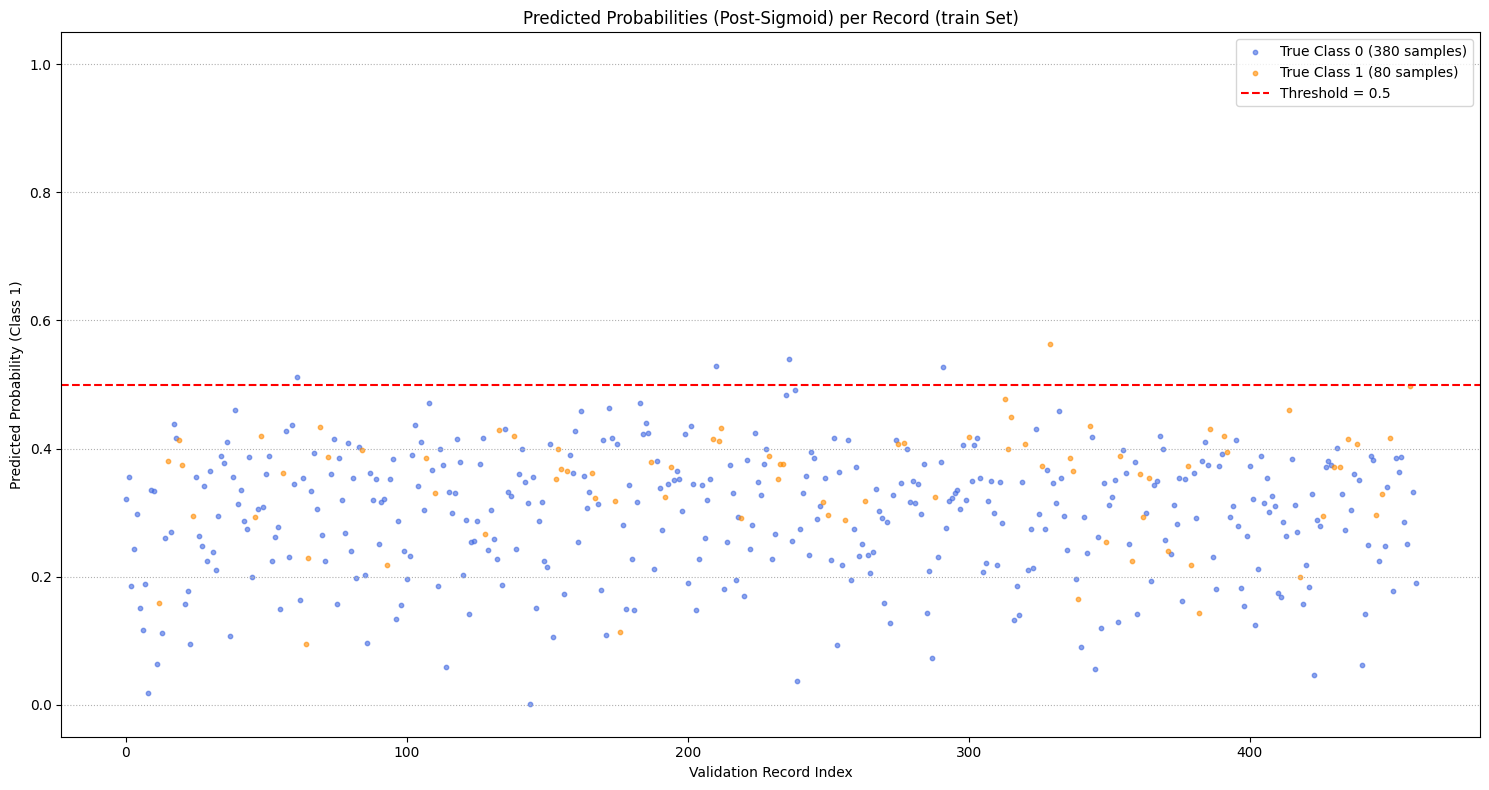

--- Probability Plotting Complete ---


In [13]:
# --- How to Use ---
# Assume 'mymodel' is your trained model returned from build_pretrained_model 
# (and potentially trained further by train_transfer_model)
# Assume 'val_dataset' is your validation tf.data.Dataset

plot_probabilities_per_record(model_for_initial_analysis, val_ds, dataset_name="train", config=my_config)


In [14]:
model_for_initial_analysis.summary()

Model: "vgg16_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 preprocessing_layer (Lambd  (None, 256, 256, 3)       0         
 a)                                                              
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 head_gap (GlobalAveragePoo  (None, 512)               0         
 ling2D)                                                         
                                                                 
 head_bn_1 (BatchNormalizat  (None, 512)               2048      
 ion)                                                            
                                                       

In [15]:
model = model_for_initial_analysis
for i, layer in enumerate(model.layers):
    if i < 4:
        layer.trainable = False
    else:
        print(f"layer {i} set to trainable")
        layer.trainable = True
print(f"Layer {15} and higher set to trainable in fine tuning step.")

model.trainable_weights

layer 4 set to trainable
layer 5 set to trainable
layer 6 set to trainable
layer 7 set to trainable
layer 8 set to trainable
layer 9 set to trainable
Layer 15 and higher set to trainable in fine tuning step.


[<tf.Variable 'head_bn_1/gamma:0' shape=(512,) dtype=float32, numpy=
 array([0.88143176, 0.9972568 , 1.0632827 , 0.9859782 , 1.0379968 ,
        0.9549562 , 1.0210478 , 0.8653844 , 0.99382263, 1.0342201 ,
        0.99753624, 0.9599232 , 0.97913426, 0.9554221 , 0.9491485 ,
        0.87629783, 1.0028113 , 0.89400893, 0.8713806 , 0.90038866,
        0.9669167 , 0.9602815 , 1.1591872 , 0.95641285, 1.1400409 ,
        0.9104136 , 0.96609294, 0.9819718 , 1.3262088 , 0.91479826,
        0.96303827, 0.9914292 , 1.0744984 , 1.0149506 , 1.0399721 ,
        1.0465885 , 1.0886241 , 1.0305048 , 0.96704113, 1.009364  ,
        0.95441896, 1.022038  , 1.0064236 , 0.93561196, 0.88860935,
        1.0916013 , 1.2941059 , 1.040363  , 1.1320016 , 0.9296186 ,
        0.94405174, 0.89168096, 0.92795044, 1.0046976 , 0.9670348 ,
        0.93224066, 0.9729966 , 1.0568566 , 0.91189957, 1.0963845 ,
        0.9489221 , 0.9639649 , 0.815293  , 1.038583  , 0.99951464,
        1.024844  , 0.9591451 , 0.9686604 , 0.9

In [16]:



# --- Using the Custom Callback ---
# Modify your `train_transfer_model` function:

def train_transfer_model(mymodel, train_dataset, val_dataset, config: Config, save_models = True,
                         initial_weights_name="initial_weights",
                         fine_tuned_weights_name="fine_tuned_weights",
                         num = 1):

    # ... (previous setup code like log_dir creation) ...
    
    # Instantiate the custom callback
    # Decide how often you want the analysis (e.g., run_freq=3 means every 3 epochs)
    # Make sure log_dir is defined before this line
    output_analysis_callback = OutputAnalysisCallback(
        validation_data=val_dataset, 
        log_dir=os.path.join(log_dir, "output_analysis"), # Save plots in a subfolder
        run_freq=3 # Example: run every 3 epochs
    )

    # Add the callback to your lists
    initial_callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True), # Consider monitoring val_auc mode='max'
        ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1), # Consider monitoring val_auc mode='max'
        tensorboard_callback,
        output_analysis_callback # Add it here
    ]
    
    # ... (compile model for initial training) ...
    
    print("**************** Starting initial training **************** ")
    initial_history = mymodel.fit(
        # ...,
        callbacks=initial_callbacks,
        # ...
    )
    
    # ... (save initial weights / history logging) ...

    if config.NUM_FINE_TUNE_EPOCHS > 0:
        # ... (fine-tuning setup: unfreeze layers, etc.) ...
        
        # Define fine-tuning callbacks, INCLUDING the analysis callback again
        fine_tune_callbacks = [
            EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True), # Consider val_auc
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1), # Consider val_auc
            tensorboard_callback,
            output_analysis_callback # Add it here too
        ]
        
        # ... (compile model for fine-tuning) ...
        
        fine_tune_history = mymodel.fit(
            # ...,
            callbacks=fine_tune_callbacks,
            # ...
        )
        
        # ... (save fine-tuned weights / history logging) ...
    
    # ... (return statement) ...